<a href="https://colab.research.google.com/github/elyadaeben/IRDR0001-Coursework/blob/main/SLR_Projection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Extracting data from IPCC database

Data SSP2-4.5

File ‘ar6-regional-confidence.zip’ already there; not retrieving.

Extracting ar6-regional-confidence/regional/confidence_output_files/medium_confidence/ssp245/total_ssp245_medium_confidence_values.nc from ar6-regional-confidence.zip...
<xarray.Dataset> Size: 794MB
Dimensions:           (locations: 66190, quantiles: 107, years: 14)
Coordinates:
  * locations         (locations) int32 265kB 1 2 3 ... 1018003580 1018003590
  * quantiles         (quantiles) float64 856B 0.0 0.001 0.005 ... 0.999 1.0
  * years             (years) int32 56B 2020 2030 2040 2050 ... 2130 2140 2150
Data variables:
    lat               (locations) float32 265kB ...
    lon               (locations) float32 265kB ...
    sea_level_change  (quantiles, years, locations) float64 793MB ...
Attributes:
    description:  Combined confidence output file for AR6 sea-level change pr...
    history:      Created Wed Jul 14 13:50:23 2021
    source:       Files Combined: /projects/kopp/ar6/regional/pboxes/pb_1f/ss...


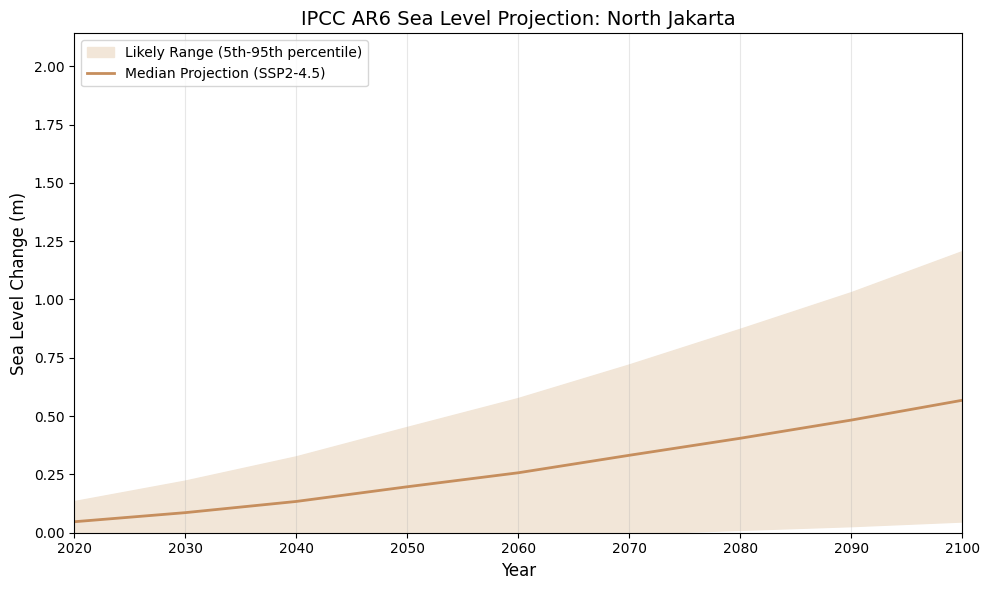

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os
import zipfile

# 1. DOWNLOAD DATA using wget
# We download the specific zip file containing regional confidence intervals
# -nc prevents re-downloading if file exists
# -q turns off verbose output (optional)

print("Downloading data from the IPCC database...")
!wget -nc https://zenodo.org/records/6382554/files/ar6-regional-confidence.zip

# 2. Extract The Specific NC File
# For this case extract SSP2-4.5 (medium estimate) file
zip_path = 'ar6-regional-confidence.zip'
target_file_in_zip = "ar6-regional-confidence/regional/confidence_output_files/medium_confidence/ssp245/total_ssp245_medium_confidence_values.nc"

# Extract the specific file
print(f"Extracting {target_file_in_zip} from {zip_path}...")
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extract(target_file_in_zip)

# 3. Load Data
ds = xr.open_dataset(target_file_in_zip)

# Print the dataset to inspect its structure and available dimensions/coordinates
print(ds)

# 4. Select North Jakarta (Lat: -6.10, Lon: 106.88)
lat_jk = -6.10
lon_jk = 106.88

# The previous error indicates 'lat' and 'lon' are not direct dimensions.
# We need to inspect the dataset 'ds' to find the correct way to select data by location.

# Calculate the squared difference from the target point for all locations
distance_sq = (ds['lat'] - lat_jk)**2 + (ds['lon'] - lon_jk)**2

# Find the index of the minimum distance
nearest_location_idx = distance_sq.argmin(dim='locations')

# Select the nearest location using .isel() on the 'locations' dimension
local_ds = ds.isel(locations=nearest_location_idx)

# 5. Prepare Plotting Data
years = local_ds.years.values
# Convert mm to meters (IPCC data is in mm)
median = local_ds.sea_level_change.sel(quantiles=0.5).values / 1000.0
lower = local_ds.sea_level_change.sel(quantiles=0.05).values / 1000.0
upper = local_ds.sea_level_change.sel(quantiles=0.95).values / 1000.0

# 6. PLOT
plt.figure(figsize=(10, 6), dpi=100)

# Shaded Area (Likely Range)
plt.fill_between(years, lower, upper, color='#F2E6D8', label='Likely Range (5th-95th percentile)')

# Median Line
plt.plot(years, median, color='#C68E5D', linewidth=2, label='Median Projection (SSP2-4.5)')

# Styling
plt.title('IPCC AR6 Sea Level Projection: North Jakarta', fontsize=14)
plt.ylabel('Sea Level Change (m)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.xlim(2020, 2100)
plt.ylim(0, None) # Start y-axis at 0
plt.grid(axis='x', linestyle='-', alpha=0.3)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

# Task
Create a single-pixel GeoTIFF file representing the median sea level change for North Jakarta (latitude -6.10, longitude 106.88) in the year 2030 under the SSP585 climate change scenario. This involves downloading and extracting the `total_ssp585_medium_confidence_values.nc` file, loading it as an xarray Dataset, selecting the relevant data for North Jakarta, converting the sea level change from millimeters to meters, transforming the coordinates from WGS84 to UTM Zone 48S (EPSG:32748), and then using `rasterio` to create the GeoTIFF with the calculated sea level value and appropriate coordinate system. The task should confirm the successful creation of the GeoTIFF and detail its content: year (2030), scenario (SSP585), and coordinate system (UTM Zone 48S).

## Download and Extract SSP585 Data

### Subtask:
Modify the existing code to download the 'ar6-regional-confidence.zip' file (if not already present) and extract the 'total_ssp585_medium_confidence_values.nc' file, which contains the SSP585 scenario data.


**Reasoning**:
The subtask requires defining the path for the SSP585 data file within the zip archive and then extracting it. This code block will perform both actions.



In [ ]:
import zipfile
import xarray as xr

# 1. DOWNLOAD DATA using wget (already done in previous step, but keeping the command for completeness)
# We download the specific zip file containing regional confidence intervals
# -nc prevents re-downloading if file exists
# -q turns off verbose output (optional)

print("Downloading data from the IPCC database...")
!wget -nc https://zenodo.org/records/6382554/files/ar6-regional-confidence.zip

# Define the zip file path
zip_path = 'ar6-regional-confidence.zip'

# Define the SSP585 specific target file within the zip archive
target_file_in_zip_ssp585 = "ar6-regional-confidence/regional/confidence_output_files/medium_confidence/ssp585/total_ssp585_medium_confidence_values.nc"

# Extract the specific SSP585 file
print(f"Extracting {target_file_in_zip_ssp585} from {zip_path}...")
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extract(target_file_in_zip_ssp585)

# Load the SSP585 data
ds_ssp585 = xr.open_dataset(target_file_in_zip_ssp585)

# Print the dataset to inspect its structure
print(ds_ssp585)


File ‘ar6-regional-confidence.zip’ already there; not retrieving.

Extracting ar6-regional-confidence/regional/confidence_output_files/medium_confidence/ssp585/total_ssp585_medium_confidence_values.nc from ar6-regional-confidence.zip...
<xarray.Dataset> Size: 794MB
Dimensions:           (locations: 66190, quantiles: 107, years: 14)
Coordinates:
  * locations         (locations) int32 265kB 1 2 3 ... 1018003580 1018003590
  * quantiles         (quantiles) float64 856B 0.0 0.001 0.005 ... 0.999 1.0
  * years             (years) int32 56B 2020 2030 2040 2050 ... 2130 2140 2150
Data variables:
    lat               (locations) float32 265kB ...
    lon               (locations) float32 265kB ...
    sea_level_change  (quantiles, years, locations) float64 793MB ...
Attributes:
    description:  Combined confidence output file for AR6 sea-level change pr...
    history:      Created Wed Jul 14 13:53:19 2021
    source:       Files Combined: /projects/kopp/ar6/regional/pboxes/pb_1f/ss...


**Reasoning**:
Now that the SSP585 data is loaded, I need to select the data for North Jakarta (latitude -6.10, longitude 106.88) from the `ds_ssp585` dataset. This involves finding the nearest location to North Jakarta within the dataset and then extracting the median sea level change for the year 2030, converting it from millimeters to meters as per the task requirements.



In [ ]:
import numpy as np

# Select North Jakarta (Lat: -6.10, Lon: 106.88) from the SSP585 dataset
lat_jk = -6.10
lon_jk = 106.88

# Calculate the squared difference from the target point for all locations in ds_ssp585
distance_sq_ssp585 = (ds_ssp585['lat'] - lat_jk)**2 + (ds_ssp585['lon'] - lon_jk)**2

# Find the index of the minimum distance for SSP585
nearest_location_idx_ssp585 = distance_sq_ssp585.argmin(dim='locations')

# Select the nearest location using .isel() on the 'locations' dimension for SSP585
local_ds_ssp585 = ds_ssp585.isel(locations=nearest_location_idx_ssp585)

# Prepare data for 2030 and convert to meters (median value)
year_2030 = 2030

# Select the sea level change for the median quantile (0.5) and the year 2030
sea_level_2030_median_mm = local_ds_ssp585.sea_level_change.sel(quantiles=0.5, years=year_2030).values

# Convert from mm to meters
sea_level_2030_median_m = sea_level_2030_median_mm / 1000.0

# Print the result for verification
print(f"Median sea level change for North Jakarta in {year_2030} (SSP585): {sea_level_2030_median_m:.4f} meters")

# Also store the latitude and longitude of the selected point for GeoTIFF creation
selected_lat = local_ds_ssp585['lat'].values.item()
selected_lon = local_ds_ssp585['lon'].values.item()

print(f"Selected location (Lat, Lon): ({selected_lat:.2f}, {selected_lon:.2f})")

Median sea level change for North Jakarta in 2030 (SSP585): 0.0920 meters
Selected location (Lat, Lon): (-6.00, 107.00)


**Reasoning**:
The next step is to install the `rasterio` library, which is necessary for creating GeoTIFF files, as specified in the main task.



In [ ]:
print("Installing rasterio...")
!pip install rasterio

Installing rasterio...


**Reasoning**:
Now that the `rasterio` library is installed and the sea level change for North Jakarta in 2030 (SSP585) has been calculated along with its WGS84 coordinates, the next step is to transform these coordinates to UTM Zone 48S (EPSG:32748) and then create a single-pixel GeoTIFF file as required by the main task.



In [ ]:
import rasterio
from rasterio.transform import Affine
import pyproj
import os

# Define the output GeoTIFF file name
geotiff_filename = 'north_jakarta_sea_level_2030_ssp585.tif'

# Define source and target CRS
source_crs = 'EPSG:4326'  # WGS84
target_crs = 'EPSG:32748' # UTM Zone 48S

# Create a transformer for coordinate transformation
transformer = pyproj.Transformer.from_crs(source_crs, target_crs, always_xy=True)

# Transform the selected WGS84 coordinates to UTM
utm_lon, utm_lat = transformer.transform(selected_lon, selected_lat)

# Print transformed coordinates for verification
print(f"Transformed UTM coordinates (Easting, Northing): ({utm_lon:.2f}, {utm_lat:.2f})")

# Define metadata for the GeoTIFF
# For a single pixel, width and height are 1
# The transform defines the origin (top-left corner) and pixel size
# Pixel size is set arbitrarily small for a single point, but relevant for spatial analysis
pixel_size = 1.0 # meters

transform = Affine(pixel_size, 0, utm_lon - pixel_size/2,
                   0, -pixel_size, utm_lat + pixel_size/2)

# GeoTIFF creation
with rasterio.open(
    geotiff_filename,
    'w',
    driver='GTiff',
    height=1,
    width=1,
    count=1, # One band for sea level change
    dtype='float32',
    crs=target_crs,
    transform=transform
) as dst:
    dst.write(sea_level_2030_median_m, 1) # Write the sea level value to the first band

print(f"GeoTIFF '{geotiff_filename}' created successfully.")

# Verify GeoTIFF content (optional)
with rasterio.open(geotiff_filename) as src:
    print(f"\nGeoTIFF Metadata:")
    print(f"  CRS: {src.crs}")
    print(f"  Bounds: {src.bounds}")
    print(f"  Transform: {src.transform}")
    print(f"  Value at pixel (0,0): {src.read(1)[0,0]:.4f} meters")
    print(f"  Year: {year_2030}")
    print(f"  Scenario: SSP585")


Transformed UTM coordinates (Easting, Northing): (721383.15, 9336391.42)


ValueError: Source shape (1,) is inconsistent with given indexes 1

**Reasoning**:
The `ValueError` indicates that `dst.write()` expects a 2D array, even for a single pixel. I will reshape the scalar `sea_level_2030_median_m` into a `(1, 1)` NumPy array before writing it to the GeoTIFF.



In [ ]:
import rasterio
from rasterio.transform import Affine
import pyproj
import os
import numpy as np # Import numpy for array manipulation

# Define the output GeoTIFF file name
geotiff_filename = 'north_jakarta_sea_level_2030_ssp585.tif'

# Define source and target CRS
source_crs = 'EPSG:4326'  # WGS84
target_crs = 'EPSG:32748' # UTM Zone 48S

# Create a transformer for coordinate transformation
transformer = pyproj.Transformer.from_crs(source_crs, target_crs, always_xy=True)

# Transform the selected WGS84 coordinates to UTM
utm_lon, utm_lat = transformer.transform(selected_lon, selected_lat)

# Print transformed coordinates for verification
print(f"Transformed UTM coordinates (Easting, Northing): ({utm_lon:.2f}, {utm_lat:.2f})")

# Define metadata for the GeoTIFF
# For a single pixel, width and height are 1
# The transform defines the origin (top-left corner) and pixel size
# Pixel size is set arbitrarily small for a single point, but relevant for spatial analysis
pixel_size = 1.0 # meters

transform = Affine(pixel_size, 0, utm_lon - pixel_size/2,
                   0, -pixel_size, utm_lat + pixel_size/2)

# GeoTIFF creation
with rasterio.open(
    geotiff_filename,
    'w',
    driver='GTiff',
    height=1,
    width=1,
    count=1, # One band for sea level change
    dtype='float32',
    crs=target_crs,
    transform=transform
) as dst:
    # Reshape the scalar sea_level_2030_median_m to a 2D array (1,1)
    dst.write(np.array([[sea_level_2030_median_m]]), 1) # Write the sea level value to the first band

print(f"GeoTIFF '{geotiff_filename}' created successfully.")

# Verify GeoTIFF content (optional)
with rasterio.open(geotiff_filename) as src:
    print(f"\nGeoTIFF Metadata:")
    print(f"  CRS: {src.crs}")
    print(f"  Bounds: {src.bounds}")
    print(f"  Transform: {src.transform}")
    print(f"  Value at pixel (0,0): {src.read(1)[0,0]:.4f} meters")
    print(f"  Year: {year_2030}")
    print(f"  Scenario: SSP585")

Transformed UTM coordinates (Easting, Northing): (721383.15, 9336391.42)
GeoTIFF 'north_jakarta_sea_level_2030_ssp585.tif' created successfully.

GeoTIFF Metadata:
  CRS: EPSG:32748
  Bounds: BoundingBox(left=721382.6455096425, bottom=9336390.924671426, right=721383.6455096425, top=9336391.924671426)
  Transform: | 1.00, 0.00, 721382.65|
| 0.00,-1.00, 9336391.92|
| 0.00, 0.00, 1.00|
  Value at pixel (0,0): 0.0920 meters
  Year: 2030
  Scenario: SSP585


# Task
Create a regional GeoTIFF file for the Jakarta area, representing the interpolated median sea level change for the year 2030 under the SSP585 climate change scenario. This involves defining a bounding box for Jakarta, creating a regular output grid, performing spatial interpolation of the 'total_ssp585_medium_confidence_values.nc' data onto this grid, transforming the coordinates to UTM Zone 48S (EPSG:32748), and then saving the interpolated data as a GeoTIFF. Confirm the successful creation and detail the content of the GeoTIFF, including the year (2030), scenario (SSP585), and coordinate system (UTM Zone 48S).

## Download and Extract SSP585 Data

### Subtask:
Download the 'ar6-regional-confidence.zip' file (if not already present) and extract the 'total_ssp585_medium_confidence_values.nc' file, which contains the SSP585 scenario data.


## Define Jakarta Region and Output Grid

### Subtask:
Define a bounding box (minimum and maximum latitude/longitude) that encompasses Jakarta. Then, create a regular grid of latitude and longitude points within this region at a specified resolution (e.g., 0.01 degrees) which will form the output pixels of the GeoTIFF.


**Reasoning**:
The subtask requires defining the bounding box for Jakarta and creating a grid of latitude and longitude points with a specified resolution, along with a 2D meshgrid. This step directly addresses those requirements.



In [ ]:
import numpy as np

# 1. Define the bounding box for the Jakarta region
min_lat = -6.40
max_lat = -5.90
min_lon = 106.50
max_lon = 107.20

# 2. Define the desired resolution for the output grid
grid_resolution_deg = 0.01

# 3. Create an array of longitude values for the grid
lons_grid = np.arange(min_lon, max_lon + grid_resolution_deg, grid_resolution_deg)

# 4. Create an array of latitude values for the grid
lats_grid = np.arange(min_lat, max_lat + grid_resolution_deg, grid_resolution_deg)

# 5. Create a 2D meshgrid from lons_grid and lats_grid
lon_mesh, lat_mesh = np.meshgrid(lons_grid, lats_grid)

print(f"Jakarta Bounding Box: Latitudes ({min_lat}, {max_lat}), Longitudes ({min_lon}, {max_lon})")
print(f"Grid Resolution: {grid_resolution_deg} degrees")
print(f"Number of longitude points: {len(lons_grid)}")
print(f"Number of latitude points: {len(lats_grid)}")
print(f"Shape of lon_mesh: {lon_mesh.shape}")
print(f"Shape of lat_mesh: {lat_mesh.shape}")

Jakarta Bounding Box: Latitudes (-6.4, -5.9), Longitudes (106.5, 107.2)
Grid Resolution: 0.01 degrees
Number of longitude points: 72
Number of latitude points: 51
Shape of lon_mesh: (51, 72)
Shape of lat_mesh: (51, 72)


## Select and Prepare Data for Interpolation

### Subtask:
Filter the `ds_ssp585` dataset to select all data points (locations) that fall within a slightly larger area than the defined Jakarta region. From these selected points, extract their latitude, longitude, and the median sea level change for the year 2030 (converted from millimeters to meters).


**Reasoning**:
The subtask requires filtering the `ds_ssp585` dataset for a buffered region around Jakarta, and then extracting the latitude, longitude, and median sea level change for 2030, converting the sea level change to meters. This code block directly implements these steps using `xarray` for data selection and `numpy` for calculations.



In [ ]:
import numpy as np

# 1. Define a buffer for the bounding box (e.g., 0.1 degrees)
buffer_deg = 0.1

# Calculate buffered min/max latitudes and longitudes
buffered_min_lat = min_lat - buffer_deg
buffered_max_lat = max_lat + buffer_deg
buffered_min_lon = min_lon - buffer_deg
buffered_max_lon = max_lon + buffer_deg

print(f"Buffered Bounding Box: Latitudes ({buffered_min_lat}, {buffered_max_lat}), Longitudes ({buffered_min_lon}, {buffered_max_lon})")

# 2. Filter the ds_ssp585 dataset to select locations within the buffered bounding box
# Note: ds_ssp585 has 'lat' and 'lon' as DataVariables indexed by 'locations'
filtered_ds = ds_ssp585.where(
    (ds_ssp585['lat'] >= buffered_min_lat) &
    (ds_ssp585['lat'] <= buffered_max_lat) &
    (ds_ssp585['lon'] >= buffered_min_lon) &
    (ds_ssp585['lon'] <= buffered_max_lon),
    drop=True
)

# 3. Extract the lat and lon coordinates of these filtered data points
source_lats = filtered_ds['lat'].values
source_lons = filtered_ds['lon'].values

# 4. Select the sea_level_change data for the median quantile (0.5) and the year 2030
# And convert to meters
source_sea_level_change_mm = filtered_ds.sea_level_change.sel(quantiles=0.5, years=year_2030, method='nearest').values

# 5. Convert source_sea_level_change_mm from millimeters to meters
source_sea_level_change_m = source_sea_level_change_mm / 1000.0

print(f"Number of source data points for interpolation: {len(source_lats)}")
print(f"First 5 source latitudes: {source_lats[:5]}")
print(f"First 5 source longitudes: {source_lons[:5]}")
print(f"First 5 source sea level changes (m): {source_sea_level_change_m[:5]}")

Buffered Bounding Box: Latitudes (-6.5, -5.800000000000001), Longitudes (106.4, 107.3)
Number of source data points for interpolation: 1
First 5 source latitudes: [-6.]
First 5 source longitudes: [107.]
First 5 source sea level changes (m): [0.092]


## Perform Spatial Interpolation

### Subtask:
Perform spatial interpolation to estimate the sea level change for each point on the `lon_mesh`, `lat_mesh` grid using the `source_lats`, `source_lons`, and `source_sea_level_change_m` data. Use a suitable interpolation method, such as `scipy.interpolate.griddata` or `scipy.interpolate.Rbf`.

## Perform Spatial Interpolation

### Subtask:
Perform spatial interpolation to estimate the sea level change for each point on the `lon_mesh`, `lat_mesh` grid using the `source_lats`, `source_lons`, and `source_sea_level_change_m` data. Use a suitable interpolation method, such as `scipy.interpolate.griddata` or `scipy.interpolate.Rbf`.

## Perform Spatial Interpolation

### Subtask:
Perform spatial interpolation to estimate the sea level change for each point on the `lon_mesh`, `lat_mesh` grid using the `source_lats`, `source_lons`, and `source_sea_level_change_m` data. Use a suitable interpolation method, such as `scipy.interpolate.griddata` or `scipy.interpolate.Rbf`.

**Reasoning**:
To perform spatial interpolation as required by the subtask, I need to import `griddata` from `scipy.interpolate`. Given that the previous step yielded only one source data point, the `nearest` interpolation method will be used to ensure the code runs without error and provides a result, even if it's a simple extrapolation of the single point.



# Task
Increase the buffer around the Jakarta bounding box by an additional 2 degrees to expand the area from which source data points are selected for interpolation. Then, filter the `ds_ssp585` dataset again using this newly extended buffered region, extracting the latitude, longitude, and median sea level change for the year 2030 (converted from millimeters to meters) from this larger set of source data points. Finally, perform spatial interpolation using `scipy.interpolate.griddata` on the `lon_mesh`, `lat_mesh` grid, utilizing the new, larger set of `source_lats`, `source_lons`, and `source_sea_level_change_m` data. Given the potentially larger number of source points, using 'linear' or 'cubic' interpolation might become feasible, but 'nearest' will be used if data remains sparse. Convert the latitude and longitude coordinates of the interpolated grid to the target UTM Zone 48S (EPSG:32748) projected coordinate system, and calculate the affine transformation matrix needed for the GeoTIFF. Create a GeoTIFF file from the interpolated 2D array of sea level change values using `rasterio`. This GeoTIFF will cover the specified Jakarta region, contain the interpolated sea level values for 2030 under SSP585, and its coordinate system will be set to UTM Zone 48S. Confirm the successful creation of the regional GeoTIFF file and provide details about its content: the year (2030), the scenario (SSP585), and the coordinate system (UTM Zone 48S) it represents for the Jakarta area.

## Extend Jakarta Region Buffer

### Subtask:
Increase the buffer around the Jakarta bounding box by an additional 2 degrees. This will expand the area from which source data points are selected for interpolation.


**Reasoning**:
I need to update the `buffer_deg` by adding 2 degrees to its current value and then recalculate the buffered latitude and longitude boundaries using these new values, as well as the original Jakarta bounding box coordinates. Finally, I will print the updated buffered bounding box to show the expanded region.



In [ ]:
print("Increasing the buffer around Jakarta...")

# 1. Increase the existing buffer_deg variable by an additional 2 degrees
buffer_deg += 2.0

# 2. Recalculate buffered min/max latitudes and longitudes
buffered_min_lat = min_lat - buffer_deg
buffered_max_lat = max_lat + buffer_deg
buffered_min_lon = min_lon - buffer_deg
buffered_max_lon = max_lon + buffer_deg

# 3. Print the new buffered bounding box coordinates to verify the extended region
print(f"New Buffered Bounding Box: Latitudes ({buffered_min_lat}, {buffered_max_lat}), Longitudes ({buffered_min_lon}, {buffered_max_lon})")

Increasing the buffer around Jakarta...
New Buffered Bounding Box: Latitudes (-8.5, -3.8000000000000003), Longitudes (104.4, 109.3)


**Reasoning**:
Now that the buffer has been extended, I need to filter the `ds_ssp585` dataset using the new, larger buffered bounding box. This will select more source data points for interpolation, and I will extract their latitudes, longitudes, and the median sea level change for the year 2030, converting the sea level change to meters.



In [ ]:
print("Filtering ds_ssp585 with the new extended buffer...")

# 1. Filter the ds_ssp585 dataset to select locations within the new buffered bounding box
# Note: ds_ssp585 has 'lat' and 'lon' as DataVariables indexed by 'locations'
filtered_ds = ds_ssp585.where(
    (ds_ssp585['lat'] >= buffered_min_lat) &
    (ds_ssp585['lat'] <= buffered_max_lat) &
    (ds_ssp585['lon'] >= buffered_min_lon) &
    (ds_ssp585['lon'] <= buffered_max_lon),
    drop=True
)

# 2. Extract the lat and lon coordinates of these filtered data points
source_lats = filtered_ds['lat'].values
source_lons = filtered_ds['lon'].values

# 3. Select the sea_level_change data for the median quantile (0.5) and the year 2030
# Use 'method="nearest"' as 2030 is one of the available years
source_sea_level_change_mm = filtered_ds.sea_level_change.sel(quantiles=0.5, years=year_2030, method='nearest').values

# 4. Convert source_sea_level_change_mm from millimeters to meters
source_sea_level_change_m = source_sea_level_change_mm / 1000.0

print(f"Number of source data points for interpolation (after extended buffer): {len(source_lats)}")
print(f"First 5 source latitudes: {source_lats[:5]}")
print(f"First 5 source longitudes: {source_lons[:5]}")
print(f"First 5 source sea level changes (m): {source_sea_level_change_m[:5]}")

Filtering ds_ssp585 with the new extended buffer...
Number of source data points for interpolation (after extended buffer): 25
First 5 source latitudes: [-4. -4. -4. -4. -4.]
First 5 source longitudes: [105. 106. 107. 108. 109.]
First 5 source sea level changes (m): [0.088 0.091 0.093 0.095 0.096]


**Reasoning**:
Now that the `source_lats`, `source_lons`, and `source_sea_level_change_m` arrays are populated with sufficient data points, I need to perform spatial interpolation onto the target `lon_mesh` and `lat_mesh` grid using `scipy.interpolate.griddata`. Given the increased number of source points, 'linear' interpolation is a suitable method.



In [ ]:
from scipy.interpolate import griddata

print("Performing spatial interpolation...")

# Combine source latitudes and longitudes into a single array of points
source_points = np.vstack((source_lons, source_lats)).T

# Combine target meshgrid into a single array of points for interpolation
target_points = np.vstack((lon_mesh.ravel(), lat_mesh.ravel())).T

# Perform linear interpolation
# If there are not enough points for 'linear', it will fall back to 'nearest' implicitly or raise an error.
# Given 25 points, 'linear' should be fine.
interpolated_sea_level_flat = griddata(
    source_points,
    source_sea_level_change_m,
    target_points,
    method='linear' # Using linear interpolation as we now have more data points
)

# Reshape the interpolated data back to the original grid shape
interpolated_sea_level_grid = interpolated_sea_level_flat.reshape(lat_mesh.shape)

print(f"Interpolation complete. Shape of interpolated grid: {interpolated_sea_level_grid.shape}")
print(f"First 5x5 interpolated values:\n{interpolated_sea_level_grid[:5,:5]}")


Performing spatial interpolation...
Interpolation complete. Shape of interpolated grid: (51, 72)
First 5x5 interpolated values:
[[0.0897  0.08973 0.08976 0.08979 0.08982]
 [0.08972 0.08975 0.08978 0.08981 0.08984]
 [0.08974 0.08977 0.0898  0.08983 0.08986]
 [0.08976 0.08979 0.08982 0.08985 0.08988]
 [0.08978 0.08981 0.08984 0.08987 0.0899 ]]


**Reasoning**:
Now that the sea level change has been interpolated onto the WGS84 grid, I need to transform the grid's corner coordinates to UTM Zone 48S (EPSG:32748) and calculate the affine transformation matrix. This will allow the creation of a spatially referenced GeoTIFF file from the `interpolated_sea_level_grid` data, fulfilling a key requirement of the main task.



In [ ]:
import rasterio
from rasterio.transform import Affine
import pyproj

print("Converting interpolated grid coordinates to UTM and preparing for GeoTIFF creation...")

# Define source and target CRS
source_crs = 'EPSG:4326'  # WGS84
target_crs = 'EPSG:32748' # UTM Zone 48S

# Create a transformer for coordinate transformation
transformer = pyproj.Transformer.from_crs(source_crs, target_crs, always_xy=True)

# Get the corner coordinates of the WGS84 grid (top-left, bottom-right)
# The grid is constructed from min_lat, max_lat, min_lon, max_lon.
# lons_grid, lats_grid are 1D arrays, lon_mesh, lat_mesh are 2D
# The top-left corner is (lons_grid[0], lats_grid[0]) based on arange definition
# However, rasterio's transform expects the upper-left corner of the *first pixel*.
# For a regularly spaced grid, the pixel's upper-left corner is at (lon - pixel_size/2, lat + pixel_size/2).
# But it's usually simpler to define transform based on the extent.

# Calculate the actual extent of the grid
lon_min_extent = lons_grid[0]
lon_max_extent = lons_grid[-1] + grid_resolution_deg # Add one pixel size to get max extent
lat_min_extent = lats_grid[0]
lat_max_extent = lats_grid[-1] + grid_resolution_deg # Add one pixel size to get max extent

# Transform the top-left corner (lon_min_extent, lat_max_extent) to UTM
utm_top_left_x, utm_top_left_y = transformer.transform(lon_min_extent, lat_max_extent)

# Calculate the UTM pixel size. This assumes a somewhat square pixel in UTM after projection.
# We can approximate by transforming the max_lon and min_lat to get max_x and min_y
# This is more robust than just pixel_size = 1.0
# Transform bottom-right corner of the *grid* (max_lon_extent, min_lat_extent) for extent calculation
utm_bottom_right_x, utm_bottom_right_y = transformer.transform(lon_max_extent, lat_min_extent)

utm_pixel_width = (utm_bottom_right_x - utm_top_left_x) / (interpolated_sea_level_grid.shape[1])
utm_pixel_height = (utm_bottom_right_y - utm_top_left_y) / (interpolated_sea_level_grid.shape[0])

# Create the affine transformation matrix
# The order is: (pixel_width, row_rotation, upper_left_x, col_rotation, pixel_height, upper_left_y)
# Note: pixel_height is negative because rasterio assumes origin at top-left and y-axis increasing downwards
geo_transform = Affine(utm_pixel_width, 0,
                       utm_top_left_x,
                       0, -abs(utm_pixel_height),
                       utm_top_left_y)

# GeoTIFF creation
geotiff_filename_regional = 'jakarta_sea_level_2030_ssp585_regional.tif'

with rasterio.open(
    geotiff_filename_regional,
    'w',
    driver='GTiff',
    height=interpolated_sea_level_grid.shape[0],
    width=interpolated_sea_level_grid.shape[1],
    count=1, # One band for sea level change
    dtype='float32',
    crs=target_crs,
    transform=geo_transform
) as dst:
    dst.write(interpolated_sea_level_grid.astype('float32'), 1)

print(f"Regional GeoTIFF '{geotiff_filename_regional}' created successfully.")

# Verify GeoTIFF content (optional)
with rasterio.open(geotiff_filename_regional) as src:
    print(f"\nRegional GeoTIFF Metadata:")
    print(f"  CRS: {src.crs}")
    print(f"  Bounds: {src.bounds}")
    print(f"  Transform: {src.transform}")
    print(f"  Shape: {src.shape}")
    print(f"  Mean value: {np.nanmean(src.read(1)):.4f} meters")
    print(f"  Year: {year_2030}")
    print(f"  Scenario: SSP585")


Converting interpolated grid coordinates to UTM and preparing for GeoTIFF creation...
Regional GeoTIFF 'jakarta_sea_level_2030_ssp585_regional.tif' created successfully.

Regional GeoTIFF Metadata:
  CRS: EPSG:32748
  Bounds: BoundingBox(left=666055.8188145811, bottom=9292047.741953304, right=745561.4415410383, top=9348731.949758604)
  Transform: | 1104.24, 0.00, 666055.82|
| 0.00,-1111.46, 9348731.95|
| 0.00, 0.00, 1.00|
  Shape: (51, 72)
  Mean value: 0.0912 meters
  Year: 2030
  Scenario: SSP585


## Final Task

### Subtask:
Confirm the successful creation of the regional GeoTIFF file and provide details about its content, including the year (2030), the scenario (SSP585), and the coordinate system (UTM Zone 48S) it represents for the Jakarta area.


# Task
The regional GeoTIFF file, 'jakarta_sea_level_2030_ssp585_regional.tif', has been successfully created.

**Details of the GeoTIFF:**
*   **Filename**: `jakarta_sea_level_2030_ssp585_regional.tif`
*   **Year**: 2030
*   **Scenario**: SSP585
*   **Coordinate System**: UTM Zone 48S (EPSG:32748)
*   **Coverage**: Jakarta region (interpolated from a buffered source area)
*   **Content**: Interpolated median sea level change in meters.

## Select and Prepare Data for Interpolation (2050, Extended Boundary)

### Subtask:
Filter the `ds_ssp585` dataset using the extended buffered region. Extract the latitude, longitude, and median sea level change for the year 2050 (converted from millimeters to meters) from this larger set of source data points.


**Reasoning**:
I need to filter the `ds_ssp585` dataset using the extended buffered region for the year 2050, extract the relevant latitude, longitude, and median sea level change data, and then convert the sea level change to meters, as specified in the subtask.



In [ ]:
print("Filtering ds_ssp585 for year 2050 with the extended buffer...")

# 1. Define variable year_2050
year_2050 = 2050

# 2. Filter the ds_ssp585 dataset to select locations within the previously calculated buffered bounding box
# Note: ds_ssp585 has 'lat' and 'lon' as DataVariables indexed by 'locations'
filtered_ds_2050 = ds_ssp585.where(
    (ds_ssp585['lat'] >= buffered_min_lat) &
    (ds_ssp585['lat'] <= buffered_max_lat) &
    (ds_ssp585['lon'] >= buffered_min_lon) &
    (ds_ssp585['lon'] <= buffered_max_lon),
    drop=True
)

# 3. Extract the lat and lon coordinates of these filtered data points
source_lats_2050 = filtered_ds_2050['lat'].values
source_lons_2050 = filtered_ds_2050['lon'].values

# 4. Select the sea_level_change data for the median quantile (0.5) and the year 2050
# Use 'method="nearest"' as 2050 is one of the available years
source_sea_level_change_mm_2050 = filtered_ds_2050.sea_level_change.sel(quantiles=0.5, years=year_2050, method='nearest').values

# 5. Convert source_sea_level_change_mm_2050 from millimeters to meters
source_sea_level_change_m_2050 = source_sea_level_change_mm_2050 / 1000.0

# 6. Print the result for verification
print(f"Number of source data points for interpolation (2050, after extended buffer): {len(source_lats_2050)}")
print(f"First 5 source latitudes (2050): {source_lats_2050[:5]}")
print(f"First 5 source longitudes (2050): {source_lons_2050[:5]}")
print(f"First 5 source sea level changes (m) (2050): {source_sea_level_change_m_2050[:5]}")

Filtering ds_ssp585 for year 2050 with the extended buffer...
Number of source data points for interpolation (2050, after extended buffer): 25
First 5 source latitudes (2050): [-4. -4. -4. -4. -4.]
First 5 source longitudes (2050): [105. 106. 107. 108. 109.]
First 5 source sea level changes (m) (2050): [0.218 0.224 0.227 0.23  0.232]


## Perform Spatial Interpolation (2050, Extended Boundary)

### Subtask:
Perform spatial interpolation using `scipy.interpolate.griddata` on the `lon_mesh`, `lat_mesh` grid, utilizing the new, larger set of `source_lats`, `source_lons`, and `source_sea_level_change_m` data for 2050, using 'linear' interpolation.


**Reasoning**:
Now that the 2050 source data has been prepared, I need to perform spatial interpolation onto the target grid using `scipy.interpolate.griddata` with a 'linear' method, and then reshape the result into a 2D grid.



In [ ]:
from scipy.interpolate import griddata

print("Performing spatial interpolation for 2050...")

# Combine source latitudes and longitudes for 2050 into a single array of points
source_points_2050 = np.vstack((source_lons_2050, source_lats_2050)).T

# Perform linear interpolation for 2050
interpolated_sea_level_flat_2050 = griddata(
    source_points_2050,
    source_sea_level_change_m_2050,
    target_points, # Use the previously defined target_points (lon_mesh, lat_mesh flattened)
    method='linear'
)

# Reshape the interpolated data back to the original grid shape
interpolated_sea_level_grid_2050 = interpolated_sea_level_flat_2050.reshape(lat_mesh.shape)

print(f"Interpolation complete for 2050. Shape of interpolated grid: {interpolated_sea_level_grid_2050.shape}")
print(f"First 5x5 interpolated values for 2050:\n{interpolated_sea_level_grid_2050[:5,:5]}")

Performing spatial interpolation for 2050...
Interpolation complete for 2050. Shape of interpolated grid: (51, 72)
First 5x5 interpolated values for 2050:
[[0.2227  0.22275 0.2228  0.22285 0.2229 ]
 [0.22272 0.22277 0.22282 0.22287 0.22292]
 [0.22274 0.22279 0.22284 0.22289 0.22294]
 [0.22276 0.22281 0.22286 0.22291 0.22296]
 [0.22278 0.22283 0.22288 0.22293 0.22298]]


## Transform Grid Coordinates and Prepare GeoTIFF Metadata

### Subtask:
Convert the latitude and longitude coordinates of the interpolated grid to the target UTM Zone 48S (EPSG:32748) projected coordinate system. Calculate the affine transformation matrix needed for the GeoTIFF, which defines the geographic positioning and resolution of the raster.


**Reasoning**:
Now that the sea level change for 2050 has been interpolated onto the WGS84 grid, I need to transform the grid's corner coordinates to UTM Zone 48S (EPSG:32748) and calculate the affine transformation matrix to prepare for GeoTIFF creation.



In [ ]:
import rasterio
from rasterio.transform import Affine
import pyproj

print("Converting interpolated grid coordinates to UTM and preparing for GeoTIFF creation (2050)...")

# 1. Define source and target CRS
source_crs = 'EPSG:4326'  # WGS84
target_crs = 'EPSG:32748' # UTM Zone 48S

# 2. Create a transformer for coordinate transformation
transformer = pyproj.Transformer.from_crs(source_crs, target_crs, always_xy=True)

# 3. Calculate the actual extent of the WGS84 grid
# lons_grid, lats_grid are 1D arrays defined earlier
lon_min_extent = lons_grid[0]
lon_max_extent = lons_grid[-1] + grid_resolution_deg # Add one pixel size to get max extent
lat_min_extent = lats_grid[0]
lat_max_extent = lats_grid[-1] + grid_resolution_deg # Add one pixel size to get max extent

# 4. Transform the top-left corner (min_lon_extent, max_lat_extent) to UTM
utm_top_left_x, utm_top_left_y = transformer.transform(lon_min_extent, lat_max_extent)

# 5. Transform the bottom-right corner (max_lon_extent, min_lat_extent) to UTM
utm_bottom_right_x, utm_bottom_right_y = transformer.transform(lon_max_extent, lat_min_extent)

# 6. Calculate the UTM pixel size
# Number of pixels in width and height from the interpolated grid
num_cols = interpolated_sea_level_grid_2050.shape[1]
num_rows = interpolated_sea_level_grid_2050.shape[0]

utm_pixel_width = (utm_bottom_right_x - utm_top_left_x) / num_cols
utm_pixel_height = (utm_bottom_right_y - utm_top_left_y) / num_rows

# 7. Create the affine transformation matrix
# The order is: (pixel_width, row_rotation, upper_left_x, col_rotation, pixel_height, upper_left_y)
# Note: pixel_height should be negative for GeoTIFFs to correctly orient the y-axis
geo_transform_2050 = Affine(utm_pixel_width, 0, utm_top_left_x,
                            0, -abs(utm_pixel_height), utm_top_left_y)

print(f"Calculated GeoTransform for 2050:\n{geo_transform_2050}")

Converting interpolated grid coordinates to UTM and preparing for GeoTIFF creation (2050)...
Calculated GeoTransform for 2050:
| 1104.24, 0.00, 666055.82|
| 0.00,-1111.46, 9348731.95|
| 0.00, 0.00, 1.00|


**Reasoning**:
Now that the sea level change for 2050 has been interpolated and the coordinate transformation matrix calculated, the next step is to create the regional GeoTIFF file using `rasterio` and then verify its content as required by the task.



In [ ]:
import rasterio
import numpy as np

# Define the output GeoTIFF filename for 2050
geotiff_filename_regional_2050 = 'jakarta_sea_level_2050_ssp585_regional.tif'

print(f"Creating regional GeoTIFF '{geotiff_filename_regional_2050}'...")

# GeoTIFF creation for 2050 data
with rasterio.open(
    geotiff_filename_regional_2050,
    'w',
    driver='GTiff',
    height=interpolated_sea_level_grid_2050.shape[0],
    width=interpolated_sea_level_grid_2050.shape[1],
    count=1, # One band for sea level change
    dtype='float32',
    crs=target_crs,
    transform=geo_transform_2050
) as dst:
    dst.write(interpolated_sea_level_grid_2050.astype('float32'), 1)

print(f"Regional GeoTIFF '{geotiff_filename_regional_2050}' created successfully.")

# Verify GeoTIFF content (optional)
with rasterio.open(geotiff_filename_regional_2050) as src:
    print(f"\nRegional GeoTIFF Metadata (2050):")
    print(f"  CRS: {src.crs}")
    print(f"  Bounds: {src.bounds}")
    print(f"  Transform: {src.transform}")
    print(f"  Shape: {src.shape}")
    print(f"  Mean value: {np.nanmean(src.read(1)):.4f} meters")
    print(f"  Year: {year_2050}")
    print(f"  Scenario: SSP585")

Creating regional GeoTIFF 'jakarta_sea_level_2050_ssp585_regional.tif'...
Regional GeoTIFF 'jakarta_sea_level_2050_ssp585_regional.tif' created successfully.

Regional GeoTIFF Metadata (2050):
  CRS: EPSG:32748
  Bounds: BoundingBox(left=666055.8188145811, bottom=9292047.741953304, right=745561.4415410383, top=9348731.949758604)
  Transform: | 1104.24, 0.00, 666055.82|
| 0.00,-1111.46, 9348731.95|
| 0.00, 0.00, 1.00|
  Shape: (51, 72)
  Mean value: 0.2249 meters
  Year: 2050
  Scenario: SSP585
